# Notebook 06 — Clasificador supervisado LightGBM sobre el modelo 05A

**Autora:** Victoria Di Liscia
**Programa:** Maestría en Explotación de Datos y Descubrimiento del Conocimiento — FCEN, UBA

## Objetivo

Cerrar el ciclo del análisis aplicando un clasificador supervisado (LightGBM multiclase) sobre las etiquetas de cluster del modelo elegido como principal — **05A (GMM sobre espacio mixto, peso 1.0)**.

El clasificador cumple **tres funciones** complementarias a la del clustering:

1. **Validación de la partición**: si las etiquetas del GMM son predecibles desde las features individuales con accuracy razonable, entonces la partición tiene **lógica estable** más allá del algoritmo de clustering. Si la accuracy es muy baja, los clusters podrían ser un artefacto.
2. **Interpretabilidad**: SHAP nos da importancia global y por clase, identificando qué variables definen cada perfil **incluyendo interacciones** (algo que los perfiles medianos del 05A no capturan).
3. **Producto reusable**: el modelo entrenado permite asignar un banco nuevo (o un mismo banco en un corte futuro) a uno de los tres perfiles sin tener que reentrenar todo el GMM.

## Estrategia

- **Features**: las 21 originales (10 continuas + 11 binarias), **sin escalar ni transformar** — LightGBM es invariante a transformaciones monótonas.
- **Evaluación honesta con n=52**: Nested Cross-Validation con outer loop de 5 folds estratificados y inner loop de 3 folds para `RandomizedSearchCV` (30 iteraciones, optimizando **macro-F1**).
- **Modelo final**: reentrenado con `RandomizedSearchCV` (CV=5, 30 iter) sobre los 52 bancos. Este modelo no tiene métrica de generalización propia — la métrica honesta viene del outer loop.
- **SHAP**: importancia global + por clase + bancos mal clasificados.

## 1. Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import RobustScaler
from sklearn.mixture import GaussianMixture
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

import lightgbm as lgb
import shap

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ROOT = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
PROCESSED = ROOT / "data" / "processed"

SEED = 42
np.random.seed(SEED)
print(f"ROOT: {ROOT}")
print(f"lightgbm: {lgb.__version__}")
print(f"shap    : {shap.__version__}")

ROOT: /Users/victoria/Documents/Maestria/tesis-perfiles-bancarios
lightgbm: 4.6.0
shap    : 0.52.0


## 2. Reconstrucción del panel + etiquetas del 05A

Reproducimos el panel de 52 bancos y reentrenamos el GMM-A para tener las etiquetas, así el notebook queda autocontenido. Es el mismo código que el del notebook 05, sección 2-6.

In [2]:
panel = pd.read_csv(PROCESSED / "panel_ratios.csv")

EXCLUIDOS = {131: "Bank of China", 165: "JPMorgan", 266: "BNP Paribas", 331: "Cetelem"}
panel = panel[~panel["codigo_entidad"].isin(EXCLUIDOS)].copy()

panel["log_activo"] = np.log(panel["activo"])
panel["titulos_sobre_activo"] = panel["TÍTULOS PÚBLICOS Y PRIVADOS"].abs() / panel["activo"]
panel["patrimonio_sobre_activo"] = panel["patrimonio"].abs() / panel["activo"]
panel["log_activo_por_empleado"] = np.log(panel["activo_por_empleado"].clip(lower=1))

FEATURES_CONT = [
    "log_activo", "prestamos_sobre_activo", "titulos_sobre_activo",
    "depositos_sobre_activo", "patrimonio_sobre_activo", "roa",
    "liquidez", "eficiencia", "cartera_irregular", "log_activo_por_empleado",
]
FEATURES_BIN = [
    "ofrece_hipoteca", "hipoteca_uva", "ofrece_personal", "ofrece_prendario",
    "ofrece_pfijo", "pfijo_uva", "ofrece_paquete", "paquete_tiene_premium",
    "ofrece_tarjeta", "tarjeta_tiene_premium", "caja_apertura_simplificada",
]
FEATURES_ALL = FEATURES_CONT + FEATURES_BIN
META = ["codigo_entidad", "nombre_banco", "tipo_entidad"]

df = panel.groupby(META)[FEATURES_ALL].mean().reset_index()
imp = SimpleImputer(strategy="median")
df_imp = df.copy()
df_imp[FEATURES_ALL] = imp.fit_transform(df[FEATURES_ALL])

LOG_VARS = ["liquidez", "cartera_irregular", "eficiencia"]

# Bloque continuo: log + RobustScaler
df_cont = df_imp[FEATURES_CONT].copy()
for v in LOG_VARS:
    df_cont[v] = np.log1p(df_cont[v])
X_cont = RobustScaler().fit_transform(df_cont)

# Bloque binario tal cual (peso 1.0)
X_bin = df_imp[FEATURES_BIN].values.astype(float)
X_05A = np.hstack([X_cont, X_bin * 1.0])

# Entrenar GMM-A para obtener las etiquetas
gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=SEED, n_init=20)
labels_05A = gmm.fit_predict(X_05A)
df_imp["y_cluster"] = labels_05A

print(f"Panel: {df_imp.shape[0]} bancos × {len(FEATURES_ALL)} features")
print(f"Distribución de clases:")
print(df_imp['y_cluster'].value_counts().sort_index().to_string())

Panel: 52 bancos × 21 features
Distribución de clases:
y_cluster
0    27
1    15
2    10


### 2.1 Naming de los clusters

Mapeamos los IDs del GMM a los nombres del resumen del 05A para que las gráficas SHAP sean legibles. Inspeccionamos el perfil de cada cluster por su ROA y depósitos sobre activo para etiquetarlos correctamente (el orden de los IDs del GMM no es determinista entre versiones de sklearn).

In [3]:
perfil = df_imp.groupby("y_cluster")[["roa", "depositos_sobre_activo", "eficiencia"]].median()
print("Perfil mediano por cluster (para nombrar):\n")
print(perfil.round(3).to_string())
print()

# Reglas para nombrar (basado en el resumen del 05A):
#   - Minoristas masivos: ROA ~3%, depósitos ~66%
#   - Chicos en transformación: ROA negativo, eficiencia ~80%
#   - Mayoristas/inversión: ROA ~3%, depósitos ~45%, eficiencia baja
def nombrar(roa, dep, efi):
    # roa y depositos_sobre_activo están en escala porcentual (0-100), no 0-1.
    if roa < 0:
        return "Chicos transformación"
    if dep < 55:
        return "Mayoristas/inversión"
    return "Minoristas masivos"

CLUSTER_NAMES = {
    cid: nombrar(perfil.loc[cid, "roa"], perfil.loc[cid, "depositos_sobre_activo"], perfil.loc[cid, "eficiencia"])
    for cid in perfil.index
}
print("Asignación de nombres:")
for cid, name in CLUSTER_NAMES.items():
    n = (df_imp["y_cluster"] == cid).sum()
    print(f"  Cluster {cid} → {name}  ({n} bancos)")

Perfil mediano por cluster (para nombrar):

             roa  depositos_sobre_activo  eficiencia
y_cluster                                           
0          3.083                  66.488      42.746
1         -2.328                  60.142      80.155
2          3.226                  45.400      30.267

Asignación de nombres:
  Cluster 0 → Minoristas masivos  (27 bancos)
  Cluster 1 → Chicos transformación  (15 bancos)
  Cluster 2 → Mayoristas/inversión  (10 bancos)


## 3. Features para el clasificador

Usamos las **21 features originales sin transformar**. LightGBM es invariante a transformaciones monótonas (es un árbol), así que `log` y `RobustScaler` no aportan. Mantener la escala original también facilita la interpretación de SHAP.

In [4]:
X = df_imp[FEATURES_ALL].values
y = df_imp["y_cluster"].values
feature_names = FEATURES_ALL

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures continuas: {len(FEATURES_CONT)}")
print(f"Features binarias : {len(FEATURES_BIN)}")

X shape: (52, 21)
y shape: (52,)

Features continuas: 10
Features binarias : 11


## 4. Nested Cross-Validation (5 outer × 3 inner)

### Por qué nested CV

Con n=52 y 3 clases muy desbalanceadas (27/15/10), si optimizamos hiperparámetros en el mismo CV que evaluamos, **inflamos la accuracy** porque el modelo se ajusta a los folds. La solución estándar es nested CV:

- **Outer loop** (5 folds estratificados): para cada fold, el modelo **no vio** esos 10-11 bancos. La métrica del outer loop es nuestra estimación honesta de generalización.
- **Inner loop** (3 folds estratificados sobre el train del outer): búsqueda de hiperparámetros con `RandomizedSearchCV`. Cada outer fold elige sus propios mejores params.

### Espacio de búsqueda

Parámetros conservadores para n=52, con 30 iteraciones de búsqueda aleatoria (más que suficiente porque la sensibilidad fina a hiperparámetros es ilusoria con tan pocos datos).

### Métrica

Optimizamos **macro-F1** (no accuracy) porque las clases están desbalanceadas (27/15/10) y nos importa que el modelo no sacrifique las clases chicas.

In [5]:
PARAM_DIST = {
    "num_leaves":        [7, 15, 31],
    "max_depth":         [3, 5, -1],
    "learning_rate":     [0.01, 0.05, 0.1],
    "n_estimators":      [100, 300, 500],
    "min_child_samples": [2, 5, 10],
    "reg_alpha":         [0.0, 0.1, 1.0],
    "reg_lambda":        [0.0, 0.1, 1.0],
}

N_ITER = 30
INNER_FOLDS = 3
OUTER_FOLDS = 5
print(f"Espacio de búsqueda: {len(PARAM_DIST)} hiperparámetros")
print(f"Iteraciones random : {N_ITER}")
print(f"Inner CV folds     : {INNER_FOLDS}")
print(f"Outer CV folds     : {OUTER_FOLDS}")

Espacio de búsqueda: 7 hiperparámetros
Iteraciones random : 30
Inner CV folds     : 3
Outer CV folds     : 5


In [6]:
def make_lgbm():
    return lgb.LGBMClassifier(
        objective="multiclass",
        num_class=3,
        class_weight="balanced",
        random_state=SEED,
        verbose=-1,
    )

outer = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED)

outer_acc = []
outer_f1  = []
outer_preds = np.zeros_like(y)
outer_best_params = []

for fold_idx, (tr, te) in enumerate(outer.split(X, y), start=1):
    inner = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=SEED)
    search = RandomizedSearchCV(
        estimator=make_lgbm(),
        param_distributions=PARAM_DIST,
        n_iter=N_ITER,
        cv=inner,
        scoring="f1_macro",
        random_state=SEED,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X[tr], y[tr])
    best = search.best_estimator_
    pred = best.predict(X[te])
    outer_preds[te] = pred
    acc = accuracy_score(y[te], pred)
    f1  = f1_score(y[te], pred, average="macro")
    outer_acc.append(acc)
    outer_f1.append(f1)
    outer_best_params.append(search.best_params_)
    print(f"Fold {fold_idx}: acc={acc:.3f}  f1={f1:.3f}  best_f1_inner={search.best_score_:.3f}")

print(f"\n{'='*60}")
print(f"Outer CV — promedio sobre {OUTER_FOLDS} folds")
print(f"  Accuracy  : {np.mean(outer_acc):.3f} ± {np.std(outer_acc):.3f}")
print(f"  Macro-F1  : {np.mean(outer_f1):.3f} ± {np.std(outer_f1):.3f}")

Fold 1: acc=0.818  f1=0.833  best_f1_inner=0.905


Fold 2: acc=0.818  f1=0.792  best_f1_inner=0.797


Fold 3: acc=1.000  f1=1.000  best_f1_inner=0.899


Fold 4: acc=0.900  f1=0.859  best_f1_inner=0.958


Fold 5: acc=0.800  f1=0.767  best_f1_inner=0.946

Outer CV — promedio sobre 5 folds
  Accuracy  : 0.867 ± 0.075
  Macro-F1  : 0.850 ± 0.081


### 4.1 Estabilidad de hiperparámetros entre folds

In [7]:
params_df = pd.DataFrame(outer_best_params)
params_df.index = [f"Fold {i+1}" for i in range(len(params_df))]
print("Mejores hiperparámetros por fold:\n")
print(params_df.to_string())
print("\n\nValores más frecuentes:")
for col in params_df.columns:
    counts = params_df[col].value_counts()
    print(f"  {col:<20} → {counts.index[0]}  ({counts.iloc[0]}/{len(params_df)} folds)")

Mejores hiperparámetros por fold:

        reg_lambda  reg_alpha  num_leaves  n_estimators  min_child_samples  max_depth  learning_rate
Fold 1         1.0        0.0           7           300                  2          3           0.01
Fold 2         0.0        0.1          31           100                  2          5           0.05
Fold 3         0.1        0.1          31           300                 10          3           0.01
Fold 4         0.1        0.0          15           300                 10          3           0.10
Fold 5         1.0        0.0          15           100                  2         -1           0.05


Valores más frecuentes:
  reg_lambda           → 1.0  (2/5 folds)
  reg_alpha            → 0.0  (3/5 folds)
  num_leaves           → 31  (2/5 folds)
  n_estimators         → 300  (3/5 folds)
  min_child_samples    → 2  (3/5 folds)
  max_depth            → 3  (3/5 folds)
  learning_rate        → 0.01  (2/5 folds)


### 4.2 Matriz de confusión agregada del outer loop

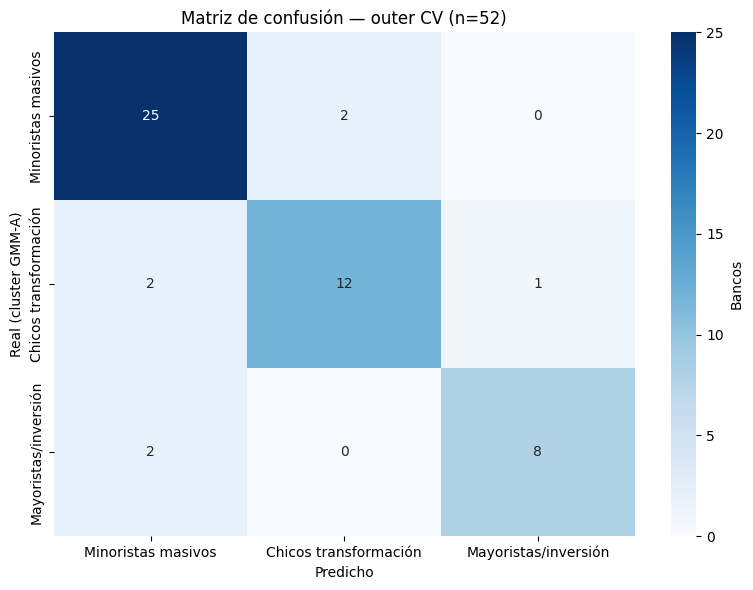


                       precision    recall  f1-score   support

   Minoristas masivos      0.862     0.926     0.893        27
Chicos transformación      0.857     0.800     0.828        15
 Mayoristas/inversión      0.889     0.800     0.842        10

             accuracy                          0.865        52
            macro avg      0.869     0.842     0.854        52
         weighted avg      0.866     0.865     0.864        52



In [8]:
cm = confusion_matrix(y, outer_preds)
class_labels = [CLUSTER_NAMES[i] for i in sorted(CLUSTER_NAMES.keys())]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={"label": "Bancos"}, ax=ax)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real (cluster GMM-A)")
ax.set_title(f"Matriz de confusión — outer CV (n={len(y)})")
plt.tight_layout(); plt.show()

print("\n" + classification_report(y, outer_preds, target_names=class_labels, digits=3))

### 4.3 Bancos mal clasificados en el outer loop

In [9]:
df_imp["pred_outer"] = outer_preds
df_imp["pred_nombre"] = df_imp["pred_outer"].map(CLUSTER_NAMES)
df_imp["real_nombre"] = df_imp["y_cluster"].map(CLUSTER_NAMES)

mal = df_imp[df_imp["y_cluster"] != df_imp["pred_outer"]].copy()
print(f"Bancos mal clasificados: {len(mal)} de {len(df_imp)} ({100*len(mal)/len(df_imp):.1f}%)\n")
cols_show = ["nombre_banco", "tipo_entidad", "real_nombre", "pred_nombre",
             "roa", "depositos_sobre_activo", "eficiencia", "cartera_irregular"]
print(mal[cols_show].sort_values("real_nombre").to_string(index=False))

Bancos mal clasificados: 7 de 52 (13.5%)

                      nombre_banco     tipo_entidad           real_nombre           pred_nombre        roa  depositos_sobre_activo  eficiencia  cartera_irregular
BANCO DE LA REPUBLICA ORIENTAL DEL       extranjero Chicos transformación  Mayoristas/inversión -35.412934               40.443874  406.775038           0.073333
               BANCO COLUMBIA S.A. privado_nacional Chicos transformación    Minoristas masivos   0.863064               44.960704  158.183877          10.333333
                   BANCO DINO S.A. privado_nacional Chicos transformación    Minoristas masivos  -3.541936               60.142486   37.723282           4.283333
 BANCO DE SANTIAGO DEL ESTERO S.A.          publico  Mayoristas/inversión    Minoristas masivos   2.470053               48.466520   21.141241           6.896667
            BANCO DE COMERCIO S.A. privado_nacional  Mayoristas/inversión    Minoristas masivos   6.378094               29.760576   36.862628      

## 5. Modelo final — entrenado sobre los 52 bancos

Para SHAP necesitamos un único modelo que use todos los datos. Hacemos `RandomizedSearchCV` con CV=5 sobre los 52 bancos. **Este modelo no tiene métrica de generalización propia** — la métrica honesta sigue siendo la del outer loop de la sección 4.

In [10]:
final_search = RandomizedSearchCV(
    estimator=make_lgbm(),
    param_distributions=PARAM_DIST,
    n_iter=N_ITER,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring="f1_macro",
    random_state=SEED,
    n_jobs=-1,
    refit=True,
)
final_search.fit(X, y)
final_model = final_search.best_estimator_

print(f"Mejor macro-F1 (CV interno, NO honesto): {final_search.best_score_:.3f}")
print(f"\nMejores hiperparámetros del modelo final:")
for k, v in final_search.best_params_.items():
    print(f"  {k:<20} = {v}")

Mejor macro-F1 (CV interno, NO honesto): 0.935

Mejores hiperparámetros del modelo final:
  reg_lambda           = 0.1
  reg_alpha            = 0.0
  num_leaves           = 15
  n_estimators         = 500
  min_child_samples    = 5
  max_depth            = 5
  learning_rate        = 0.1


## 6. SHAP — interpretación del clasificador

### 6.1 Importancia global de features

Importancia global (|SHAP| promedio sobre clases y bancos):

roa                           1.3187
cartera_irregular             0.8519
eficiencia                    0.6549
ofrece_paquete                0.5820
prestamos_sobre_activo        0.5043
paquete_tiene_premium         0.4547
log_activo                    0.2300
ofrece_hipoteca               0.2280
log_activo_por_empleado       0.2175
depositos_sobre_activo        0.1887
ofrece_personal               0.0724
hipoteca_uva                  0.0448
liquidez                      0.0384
patrimonio_sobre_activo       0.0344
ofrece_tarjeta                0.0331
titulos_sobre_activo          0.0246
pfijo_uva                     0.0134
caja_apertura_simplificada    0.0073
ofrece_prendario              0.0000
ofrece_pfijo                  0.0000
tarjeta_tiene_premium         0.0000


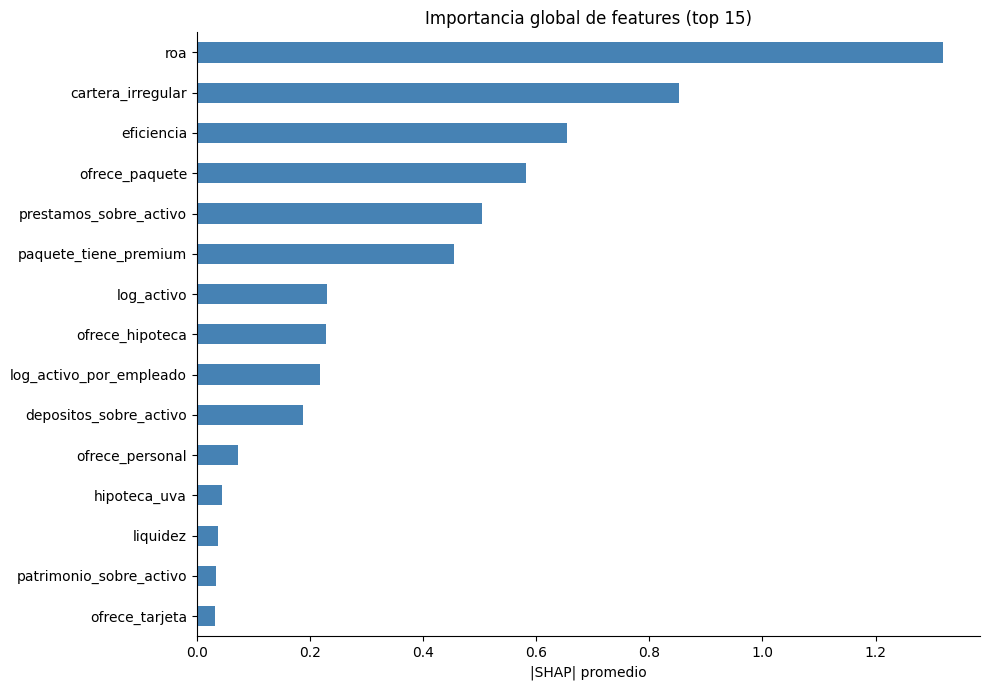

In [11]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

# shap.TreeExplainer para LGBM multiclase devuelve un array 3D
# de shape (n_samples, n_features, n_classes) — lo normalizamos a
# lista de arrays (n_samples, n_features) por clase para los plots.
if isinstance(shap_values, list):
    shap_list = shap_values
else:
    shap_list = [shap_values[:, :, k] for k in range(shap_values.shape[2])]

# Importancia global = promedio del |SHAP| sumando sobre clases
abs_shap = np.mean([np.abs(s) for s in shap_list], axis=0)
imp_global = pd.Series(abs_shap.mean(axis=0), index=feature_names).sort_values(ascending=False)

print("Importancia global (|SHAP| promedio sobre clases y bancos):\n")
print(imp_global.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
imp_global.head(15).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("|SHAP| promedio"); ax.set_title("Importancia global de features (top 15)")
plt.tight_layout(); plt.show()

### 6.2 Importancia por clase

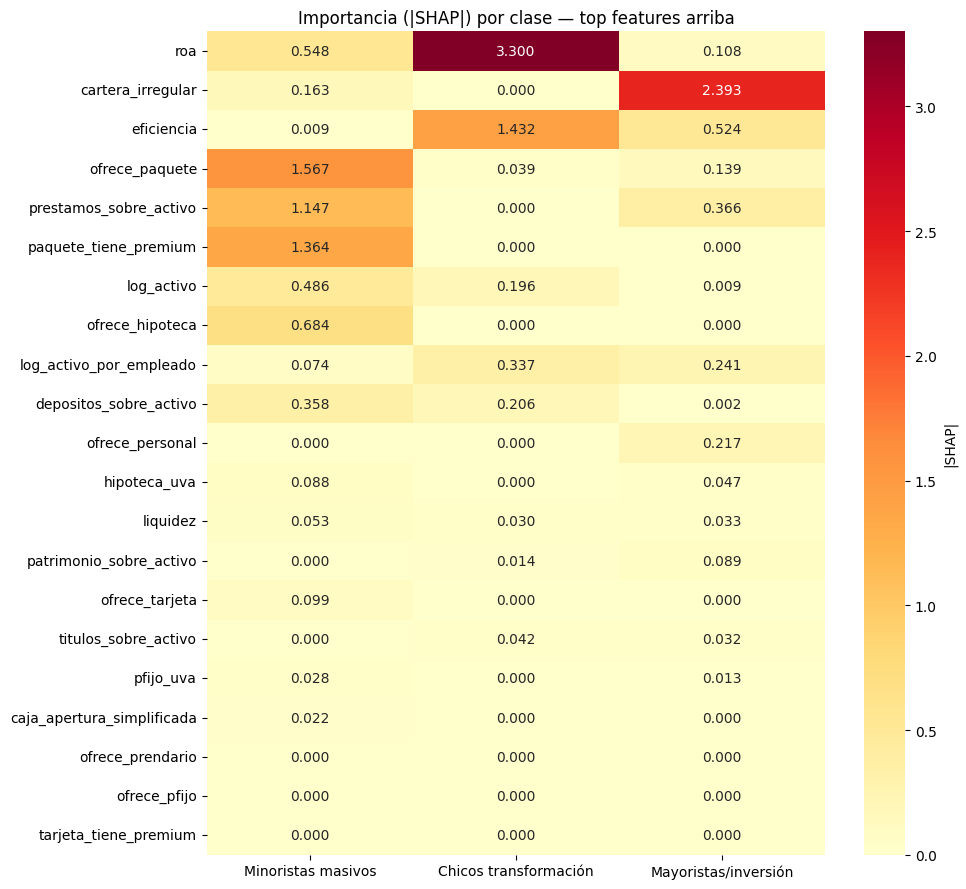


Features más importantes para cada clase (top 5):

  Minoristas masivos:
    ofrece_paquete                   1.5672
    paquete_tiene_premium            1.3642
    prestamos_sobre_activo           1.1469
    ofrece_hipoteca                  0.6840
    roa                              0.5481

  Chicos transformación:
    roa                              3.3003
    eficiencia                       1.4322
    log_activo_por_empleado          0.3374
    depositos_sobre_activo           0.2060
    log_activo                       0.1955

  Mayoristas/inversión:
    cartera_irregular                2.3925
    eficiencia                       0.5236
    prestamos_sobre_activo           0.3661
    log_activo_por_empleado          0.2412
    ofrece_personal                  0.2171



In [12]:
imp_por_clase = pd.DataFrame({
    CLUSTER_NAMES[k]: np.abs(shap_list[k]).mean(axis=0)
    for k in range(len(shap_list))
}, index=feature_names)

# Ordenar por suma de importancias para el heatmap
order = imp_por_clase.sum(axis=1).sort_values(ascending=False).index
imp_por_clase = imp_por_clase.loc[order]

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(imp_por_clase, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={"label": "|SHAP|"}, ax=ax)
ax.set_title("Importancia (|SHAP|) por clase — top features arriba")
plt.tight_layout(); plt.show()

print("\nFeatures más importantes para cada clase (top 5):\n")
for clase in imp_por_clase.columns:
    top = imp_por_clase[clase].sort_values(ascending=False).head(5)
    print(f"  {clase}:")
    for f, v in top.items():
        print(f"    {f:<32} {v:.4f}")
    print()

### 6.3 SHAP summary plot por clase


## SHAP summary — Clase 0: Minoristas masivos



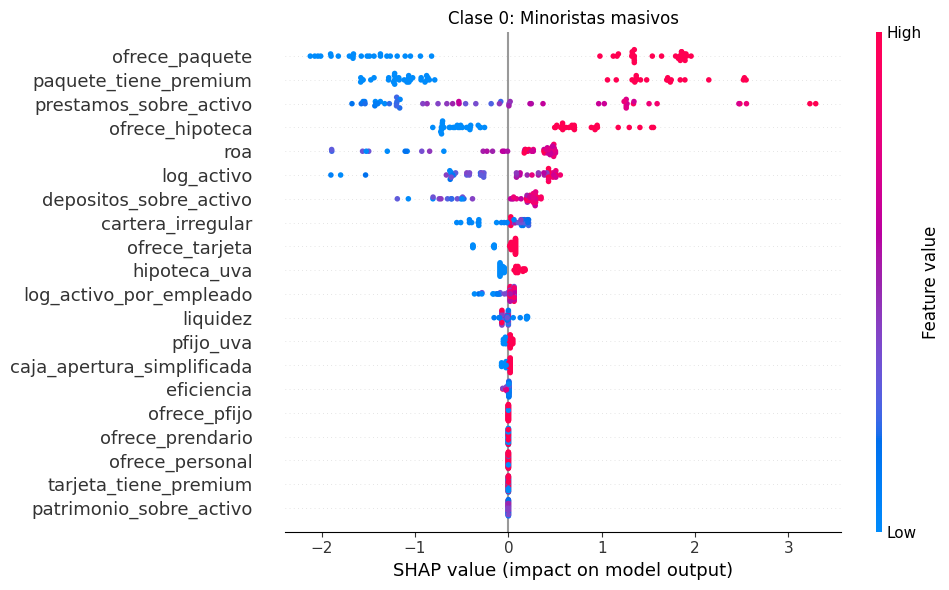


## SHAP summary — Clase 1: Chicos transformación



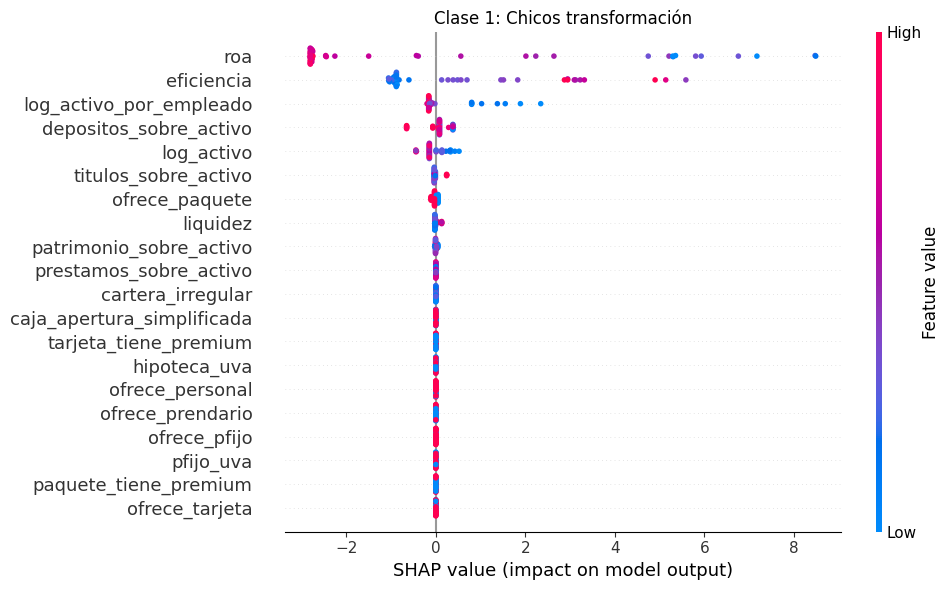


## SHAP summary — Clase 2: Mayoristas/inversión



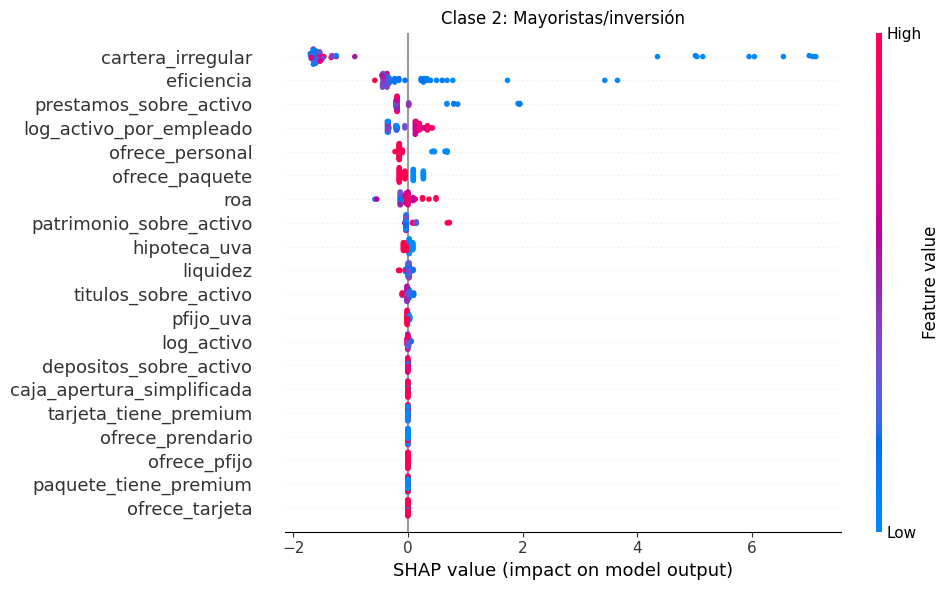

In [13]:
for k in sorted(CLUSTER_NAMES.keys()):
    print(f"\n## SHAP summary — Clase {k}: {CLUSTER_NAMES[k]}\n")
    shap.summary_plot(shap_list[k], X, feature_names=feature_names, show=False, plot_size=(10, 6))
    plt.title(f"Clase {k}: {CLUSTER_NAMES[k]}")
    plt.tight_layout(); plt.show()

### 6.4 Lectura de los summary plots

Cada plot muestra, para una clase:
- En el eje Y: features ordenadas por importancia.
- En el eje X: el valor SHAP (cuánto contribuye esa feature a la probabilidad de la clase).
- El color: el valor de la feature (rojo = alto, azul = bajo).

Esperamos:
- **Minoristas masivos**: SHAP positivo cuando `depositos_sobre_activo` y `ofrece_paquete` son altos.
- **Chicos en transformación**: SHAP positivo cuando `roa` es bajo (negativo) y `eficiencia` es alta.
- **Mayoristas/inversión**: SHAP positivo cuando `depositos_sobre_activo` y `ofrece_paquete` son bajos.

## 7. Conclusiones del notebook 06

*Esta sección se completa con los números reales una vez ejecutado el notebook.*

### Preguntas que respondemos

1. **¿Las etiquetas del 05A son predecibles desde las features?**
   - Outer CV accuracy: ver sección 4.
   - Si la accuracy es > 0.85 → los clusters son **fácilmente predecibles**; la estructura es real y reproducible más allá del GMM.
   - Si está entre 0.65 y 0.80 → estructura razonable, con fronteras borrosas (consistente con silhouette 0.145).
   - Si es < 0.6 → alarma: los clusters podrían ser artefacto del GMM.

2. **¿Qué features definen cada perfil?**
   - Ver SHAP por clase (sección 6.2 y 6.3).
   - Comparar con los perfiles medianos del resumen del 05A. ¿Coinciden las variables?

3. **¿Los errores tienen sentido?**
   - Listar los bancos mal clasificados (sección 4.3).
   - Si son los "intermedios" mencionados en el resumen (BICA, BancoSol, etc.), es **buena señal**: el clasificador encuentra los mismos continuos que el GMM.

4. **¿Los hiperparámetros son estables?**
   - Si los 5 folds del outer loop convergen a hiperparámetros similares (sección 4.1), hay una configuración robusta.
   - Si oscilan mucho, hay sobre-ajuste o señal débil.

### Próximos pasos sugeridos

- Si la performance es buena: usar el modelo final para clasificar futuros cortes (Dic-26, etc.) sin reentrenar el GMM.
- Comparar SHAP con los loadings de PCA del 05A — ¿coinciden las variables más discriminantes?
- Si querés validación cualitativa adicional: probar predecir un grupo de bancos pequeños chilenos o uruguayos (transferibilidad).